# Population ESP composites: selection audit
Run on Katana first. This produces a frozen manifest for **AE/CE × planetary/topographic** composites. The initial product uses valid ESP geometry and complete profiles, not a claim of validated reconstruction skill. Existing final surface tables contain no interpolation provenance; this limitation is recorded for every row. No outcome-based tilt filter is used.

Quality thresholds below are provisional and transparent. Inspect retention before interpreting results. Mixed days remain in the audit but are outside the initial four composites.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subdirectory')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
import seacofs_tilt_tools as tilt
import population_tools as pop
pd.set_option('display.max_columns', 60)


In [2]:
# Exact cached levels nearest these targets; no vertical interpolation.
TARGET_DEPTHS_M = (0., 200., 500.)
MAX_DEPTH_DISTANCE_M = 60.
DOMINANCE_FACTOR = 2.
MIN_SLOPE = 1e-4  # m/m, net core-mean bathymetric gradient
MIN_SLOPE_COHERENCE = 0.5
MIN_SLOPE_VALID_FRACTION = 0.8
HORIZONTAL_UNITS = 'Rc'  # one reference Rc for the whole column
HALF_WIDTH = 3.0        # use e.g. 100 if units='km'
GRID_STEP = 0.2         # use e.g. 5 if units='km'
MASK_OCEAN = True      # native wet/bathymetric support at each transformed point
N_BOOT = 500
MIN_EDDIES = 20        # pointwise display threshold, not a guarantee of precision
SEED = 731
ESP_ROOT = '/home/z5297792/ESP_zonodo'
OUTPUT_ROOT = Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/esp_population_composites')
paths = tilt.Paths()
PV_PATH = tilt.DEFAULT_DEPTH_PV_ROOT/tilt.DEPTH_PV_SNAPSHOT_NAME


In [3]:
surface = tilt.read_table(paths.eddies)
vertical = tilt.load_vert(paths)
pv = pd.read_parquet(PV_PATH)
pop.unique(surface, pop.KEYS)
pop.unique(vertical, pop.KEYS+['Depth'])
pop.unique(pv, pop.KEYS)
depths = pop.select_depths(vertical, TARGET_DEPTHS_M, MAX_DEPTH_DISTANCE_M)
print('Requested:', TARGET_DEPTHS_M, 'Exact fitted levels:', depths)
# This reference depth is used for EVERY eddy-day, even if some profiles have shallower levels.
print('Common reference depth:', depths[0])
catalogue = vertical.groupby('Depth').size().rename('eddy_days').to_frame()
display(catalogue)
audit, fitted = pop.audit_population(surface, vertical, pv, depths, DOMINANCE_FACTOR)
grid = tilt.load_grid(paths.grid, paths.z_r)
audit = pop.add_frames(audit, grid, min_slope=MIN_SLOPE,
                       min_coherence=MIN_SLOPE_COHERENCE, min_fraction=MIN_SLOPE_VALID_FRACTION)


Requested: (0.0, 200.0, 500.0) Exact fitted levels: [  0.         181.26479327 515.41648935]
Common reference depth: 0.0


,eddy_days
Depth,
0.000000,120543
5.879627,120543
10.725783,120543
16.383097,119527
22.925581,118927
30.444118,118488
39.052712,118103
48.897638,117700
60.170639,117260


## Attrition and population balance
Inspect both numbers of eddies and days. Basic validity exclusions can overlap. Missing deep profiles may preferentially remove shallower eddies; compare with a shallower run. Slope-direction failures only exclude slope-aligned composites. Neither tilt magnitude nor agreement with a hypothesised direction determines membership.

candidate_days  candidate_eddies  basic_eligible_days  \
Cyc regime                                                               
AE  Mixed                 17884               985                14987   
    Planetary              4464               502                 3926   
    Topographic           39205              1416                29028   
    Unknown                3399              1005                    0   
CE  Mixed                 10509               858                 9450   
    Planetary              1653               371                 1528   
    Topographic           46828              1528                39707   
    Unknown                3484              1063                    0   

                 selected_days  
Cyc regime                      
AE  Mixed                    0  
    Planetary             3926  
    Topographic          19353  
    Unknown                  0  
CE  Mixed                    0  
    Planetary             1528  
    Topographic          29000  
    Unknown                  0

exclusion_reason
                                                                  53807
mixed_regime_not_in_initial_four                                  24437
missing_depth|invalid_fit                                         21917
unreliable_slope_frame                                            20382
missing_depth|invalid_fit|polarity_inconsistent|missing_regime     6883
Name: days, dtype: int64

,eddies,days
group,,
AE_Planetary,382,3926
AE_Topographic,1190,19353
CE_Planetary,317,1528
CE_Topographic,1407,29000


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
AE_Planetary,382.0,10.277487,13.868579,1.0,2.0,6.0,14.0,112.0
AE_Topographic,1190.0,16.263025,16.700263,1.0,5.0,13.0,22.0,213.0
CE_Planetary,317.0,4.820189,4.972949,1.0,1.0,3.0,6.0,29.0
CE_Topographic,1407.0,20.611230,16.310648,1.0,9.0,18.0,28.0,170.0


lat                               lon              \
                   median        min        max      median         min   
group                                                                     
AE_Planetary   -35.424460 -40.446939 -26.206449  153.903619  151.624421   
AE_Topographic -33.840183 -40.897018 -26.248340  155.770943  148.691515   
CE_Planetary   -35.538277 -40.755321 -26.489223  154.594548  151.819757   
CE_Topographic -33.381120 -40.308683 -25.712362  154.843659  148.587650   

                                    Rc                               Ro  \
                       max      median        min         max    median   
group                                                                     
AE_Planetary    159.023987  103.631613  24.714837  261.990262 -0.162421   
AE_Topographic  161.404583   75.873334  19.612385  284.541529 -0.126136   
CE_Planetary    160.464519   85.475548  26.828749  172.438647  0.129762   
CE_Topographic  161.697336   66.434162  16.176858  208.932681  0.136468   

                                              h                            \
                     min       max       median          min          max   
group                                                                       
AE_Planetary   -0.519258 -0.042964  4847.825633  2497.302009  4880.779206   
AE_Topographic -0.471674 -0.022608  4418.221571  1118.917151  4865.683974   
CE_Planetary    0.029192  0.542917  4720.614458  1651.535785  4886.048289   
CE_Topographic  0.022783  1.352862  3938.946943   518.515586  4873.709539   

               slope_strength                     slope_coherence            \
                       median       min       max          median       min   
group                                                                         
AE_Planetary              NaN       NaN       NaN             NaN       NaN   
AE_Topographic       0.009293  0.000464  0.110723        0.827827  0.500013   
CE_Planetary              NaN       NaN       NaN             NaN       NaN   
CE_Topographic       0.012258  0.000472  0.119735        0.879912  0.500001   

                          
                     max  
group                     
AE_Planetary         NaN  
AE_Topographic  0.999780  
CE_Planetary         NaN  
CE_Topographic  0.999904

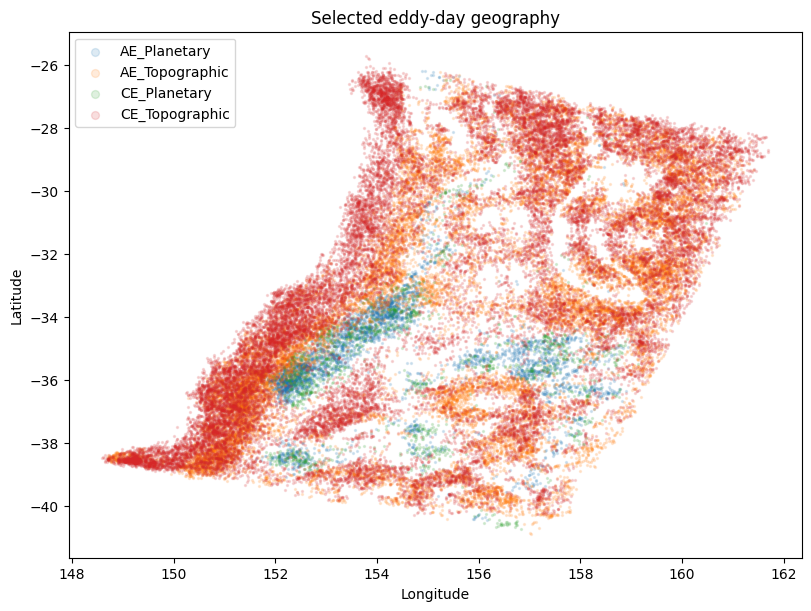

In [4]:
display(audit.groupby(['Cyc','regime'], observed=True).agg(
    candidate_days=('Day','size'), candidate_eddies=('Eddy','nunique'),
    basic_eligible_days=('eligible','sum'), selected_days=('selected','sum')))
display(audit.exclusion_reason.value_counts(dropna=False).rename('days'))
selected = audit.loc[audit.selected].copy()
if selected.empty:
    raise ValueError('No selected eddy-days; inspect the audit and depth catalogue')
display(selected.groupby('group').agg(eddies=('Eddy','nunique'),days=('Day','size')))
display(selected.groupby(['group','Eddy']).size().groupby('group').describe())
columns = [c for c in ['lat','lon','Rc','Ro','h','slope_strength','slope_coherence'] if c in selected]
display(selected.groupby('group')[columns].agg(['median','min','max']))
fig, ax = plt.subplots(figsize=(8,6), constrained_layout=True)
for group, part in selected.groupby('group'):
    ax.scatter(part.lon, part.lat, s=2, alpha=.15, label=group)
ax.set(xlabel='Longitude', ylabel='Latitude', title='Selected eddy-day geography')
ax.legend(markerscale=4)
plt.show()


## Freeze selection and source metadata
Outputs use a configuration/source-metadata hash. A separate hash is generated for different depths, thresholds, normalisation or inputs. Full source-file contents are not hashed. Reconstruction will verify the stored file sizes and modification times. The audit records the processed-surface provenance limitation; it does not invent an observed-only flag.

In [5]:
config = dict(depths=depths.tolist(), target_depths=list(TARGET_DEPTHS_M),
              dominance=DOMINANCE_FACTOR, min_slope=MIN_SLOPE,
              min_slope_coherence=MIN_SLOPE_COHERENCE,
              min_slope_valid_fraction=MIN_SLOPE_VALID_FRACTION,
              units=HORIZONTAL_UNITS, half_width=HALF_WIDTH, grid_step=GRID_STEP,
              mask_ocean=MASK_OCEAN, n_boot=N_BOOT, min_eddies=MIN_EDDIES,
              seed=SEED, esp_root=ESP_ROOT,
              velocity_convention='existing SEACOFS ESP: east/north output; model-grid x/y inputs')
run_id, provenance = pop.fingerprint(config, [paths.eddies, paths.vert, PV_PATH, paths.grid, paths.z_r, Path(ESP_ROOT)/'functions.py'])
run = OUTPUT_ROOT/run_id
run.mkdir(parents=True, exist_ok=True)
audit.to_parquet(run/'audit.parquet', index=False)
selected.to_parquet(run/'selected.parquet', index=False)
fitted.merge(selected[pop.KEYS], on=pop.KEYS, validate='many_to_one').to_parquet(run/'profiles.parquet', index=False)
(run/'provenance.json').write_text(json.dumps(provenance, indent=2))
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT/'latest_run.txt').write_text(str(run))
print('Frozen run:', run)
print('Next: 01_polarity_regime_composites.ipynb')


Frozen run: /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/esp_population_composites/39f937013b2719bf
Next: 01_polarity_regime_composites.ipynb
